In [1]:

import glob
import pandas as pd
import os
import pyarrow as pa
import numpy as np
import pyarrow.parquet as pq
import re


from scipy.stats import spearmanr, pearsonr
from export_floats import store_to_tex

In [2]:
linear_coder = "MSECoderProjUSimp"

In [3]:
def format_corr_with_stars(corr, p):
    if pd.isna(corr) or pd.isna(p):
        return ''
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = ''
    return f"{corr:.2f}{stars}"

def get_background_color_from_corr(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'background-color: white'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'background-color: white'
    abs_corr = max(0.0, min(1.0, abs(corr)))
    DARK_R, DARK_G, DARK_B = 50, 150, 200
    WHITE = 255
    r = int(WHITE - abs_corr * (WHITE - DARK_R))
    g = int(WHITE - abs_corr * (WHITE - DARK_G))
    b = int(WHITE - abs_corr * (WHITE - DARK_B))
    return f'background-color: rgb({r}, {g}, {b})'

def get_text_color_for_contrast(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'color: black'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'color: black'
    return 'color: white' if abs(corr) >= 0.6 else 'color: black'

def get_background_color_from_corr(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'background-color: white'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'background-color: white'
    abs_corr = max(0.0, min(1.0, abs(corr)))
    DARK_R, DARK_G, DARK_B = 50, 150, 200
    WHITE = 255
    r = int(WHITE - abs_corr * (WHITE - DARK_R))
    g = int(WHITE - abs_corr * (WHITE - DARK_G))
    b = int(WHITE - abs_corr * (WHITE - DARK_B))
    return f'background-color: rgb({r}, {g}, {b})'

def get_text_color_for_contrast(val):
    match = re.match(r"([+-]?\d+\.\d+)", str(val))
    if not match:
        return 'color: black'
    try:
        corr = float(match.group(1))
    except ValueError:
        return 'color: black'
    return 'color: white' if abs(corr) >= 0.6 else 'color: black'

In [4]:

def rename_model(x):
       if x == "OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42":
              return "Olmo2-1B"
       
def rename_estimator(x):
      return x.split(":")[0]
def rename_linear_coder(x):
      return x.replace("Coder","").replace("Thresh","")
def extract_seed(x):
       return int(re.search(r'seed (\d+)', x).group(1)) if "seed" in x else None

def rename_random(x):
    return re.sub(r' with seed \d+', "", x)



df_validation = pq.ParquetDataset("results/validation").read().to_pandas()
df_validation["model"]  = df_validation["model"].apply(rename_model)
df_validation["estimator"]  = df_validation["estimator"].apply(rename_estimator)


In [5]:
def extract_k(explanation_type):
    if "The test instance (as a sanity check)" in explanation_type:
        return 1
    first_number_match = re.match(r"^\s*(\d+)\b", explanation_type)
    if first_number_match:
        return int(first_number_match.group(1))


    top_match = re.search(r"Top-(\d+)", explanation_type)
    if top_match:
        return int(top_match.group(1))

    random_match = re.search(r"(\d+)\s+random examples", explanation_type)
    if random_match:
        return int(random_match.group(1))

    return None

def replace_k(explanation_type, k):
    if k is None:
        return explanation_type
    # Only replace the first occurrence of the number as a standalone word
    return re.sub(rf"\b{k}\b", "X", explanation_type, count=1)

def vectorized_replace_k(explanation_types, ks):
    result = explanation_types.copy()
    for k in np.unique(ks[ks.notnull()]):  # only unique, non-null ks
        # Use string pattern, not compiled regex
        pattern = rf"\b{k}\b"
        mask = ks == k
        result.loc[mask] = result.loc[mask].str.replace(pattern, "X", n=1, regex=True)
    return result

def facility_location_hotfix(x):
    if ("facility" in x) and x.startswith("Top-"):
        return x[len("Top-"):]
    else:
        return x
def get_sort_type(x):
    for sort_type in ["scores with largest absolute value", "most positive scores", "most negative scores", "scores closest to zero"]:
        if sort_type in x:
            return sort_type
    return "-"





df_validation["k"] = df_validation["explanation_type"].apply(extract_k)
df_validation["explanation_type_no_k"] = vectorized_replace_k(df_validation["explanation_type"], df_validation["k"])
df_validation["explanation_type"] = df_validation["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections



df_validation["sort_type"] = df_validation["explanation_type"].apply(get_sort_type)

df_validation_random = df_validation[df_validation["explanation_type"].str.contains("random examples with seed")]
df_validation_selection = df_validation[~df_validation["explanation_type"].str.contains("random examples with seed")]



In [6]:
df_scoring = pq.ParquetDataset("results/scoring").read().to_pandas()

df_scoring["NMSE"] =1.0 / (df_scoring["pred_gain"] + 1e-10)
df_scoring["k"] = df_scoring["explanation_type"].apply(extract_k)
df_scoring["explanation_type_no_k"] = df_scoring.apply(
    lambda row: row["explanation_type"].replace(str(row["k"]), "X"),
    axis=1
)
df_scoring["explanation_type"] = df_scoring["explanation_type"].apply(facility_location_hotfix) # hotfix: inconsistent naming scheme for facility location selections
df_scoring["model"] = df_scoring["model"].apply(rename_model)
df_scoring["estimator"] = df_scoring["estimator"].apply(rename_estimator)
df_scoring["fl"] = df_scoring["explanation_type"].apply(lambda x: "FL" if "facility" in x else "N")
import re

def get_lambda(x):
    match = re.search(r'lambda=([\d.]+)', x)
    return float(match.group(1)) if match else "-"

df_scoring["lambda"] = df_scoring["explanation_type"].apply(get_lambda)
import re

def remove_lambda(expr: str):
    # remove substrings like lambda=0.5 or lambda = 0.1
    return re.sub(r'lambda\s*=\s*[\d.]+', 'lambda=X', expr)

df_scoring["explanation_type_no_lambda"] = (
    df_scoring["explanation_type"].apply(remove_lambda)
)


In [7]:
# pair selection and random validation scores
r = pd.merge(
                df_validation_selection,
                df_validation_random,
                on=[
                    "model",
                    "estimator",
                    "train_dataset",
                    "train_split",
                    "test_dataset",
                    "test_split",
                    "k",
                    "document_idx"
                ],
                suffixes=("_selection", "_random"),
                how="inner"
            )
r["validation_score_log_p"] = r["delta_log_p_selection"] - r["delta_log_p_random"]
r["validation_score_jsd"] = r["jsd_selection"] / r["jsd_random"]
r["validation_score_kld"] = r["kld(before||after)_selection"] - r["kld(before||after)_random"]



In [8]:
# merge with our score
rr = pd.merge(
    r,
    df_scoring,
    left_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type_selection", 
        "k",
        "document_idx"
    ],
    right_on=[
        "model",
        "estimator",
        "train_dataset",
        "train_split",
        "test_dataset",
        "test_split",
        "explanation_type", 
        "k",
        "document_idx"
    ],
    suffixes=("_validation", "_scoring"),
    how="left"
)


 
                

## Validity

In [9]:
df = rr.reset_index()
df = df[(df["linear_coder"]=="MSECoderProjUSimp")]
df = df[df["explanation_type_selection"].str.contains("sanity")]


In [10]:
import numpy as np
from scipy.stats import ttest_rel, wilcoxon


def remove_nans(a, b):
    mask = a.notna() & b.notna()
    a, b = a[mask], b[mask]
    return a, b


print(ttest_rel(*remove_nans(df["delta_log_p_selection"], df["delta_log_p_random"]),
                alternative="greater"))
print(ttest_rel(*remove_nans(df["jsd_selection"], df["jsd_random"]),
                alternative="greater"))


print(wilcoxon(*remove_nans(df["delta_log_p_selection"], df["delta_log_p_random"]),
               alternative="greater"))
print(wilcoxon(*remove_nans(df["jsd_selection"], df["jsd_random"]),
               alternative="greater"))


TtestResult(statistic=193.2695164927735, pvalue=0.0, df=14864)
TtestResult(statistic=11.633250550116342, pvalue=1.9050632188069862e-31, df=14864)
WilcoxonResult(statistic=110170247.0, pvalue=0.0)
WilcoxonResult(statistic=109723332.0, pvalue=0.0)


In [11]:
a,b = remove_nans(df["delta_log_p_selection"], df["delta_log_p_random"])
store_to_tex("fractionDeltaLogPSelectionLarger", f"{np.mean(a > b)*100:.2f}\%")

In [12]:
a,b = remove_nans(df["jsd_selection"], df["jsd_random"])
store_to_tex("fractionJSDSelectionLarger", f"{np.mean(a > b)*100:.2f}\%")

## Correlation Analysis

In [13]:
def compute_and_export_correlations(rr, subset_filter=None, group_cols=None, sort_cols=None,
                                    row_label_cols=None, filename="./tables/validation.tex", caption="Correlation table"):
    """
    Compute correlations of pred_gain vs validation scores and export to LaTeX.
    
    subset_filter: function to filter rr and rr_summary (takes DataFrame, returns filtered DataFrame)
    group_cols: list of columns to group by
    sort_cols: list of columns to sort by in the final table
    row_label_cols: list of columns to use as row labels (index) in the table
    """

    rr_subset = rr.copy()
       
                     

    if subset_filter:
        rr_subset = subset_filter(rr_subset)



    rows = []
    
    for keys, df in rr_subset.groupby(group_cols):
        if len(df) < 2:
            rows.append({**dict(zip(group_cols, keys)),
                         "spearman_pred_gain_log_p": "",
                         "spearman_pred_gain_jsd": "",
          })
            continue
            
        from scipy.stats import rankdata
        mask = df["pred_gain"].notna() & df["validation_score_log_p"].notna()
        x_rank = rankdata(df.loc[mask, "pred_gain"])
    
        y_rank = rankdata(df.loc[mask, "validation_score_log_p"])
        s_logp_rho = np.corrcoef(x_rank, y_rank)[0, 1]
    
        y_rank = rankdata(df.loc[mask, "validation_score_jsd"])
        s_jsd_rho  = np.corrcoef(x_rank, y_rank)[0, 1]


        rows.append({**dict(zip(group_cols, keys)),
                     "spearman_pred_gain_log_p": s_logp_rho,
                    "spearman_pred_gain_jsd": s_jsd_rho,
                    "n": mask.sum()
             })

    pooled_df = pd.DataFrame(rows)

    if row_label_cols:
        pooled_df.set_index(row_label_cols, inplace=True)
    else:
        pooled_df.set_index(group_cols, inplace=True)

    correlation_cols = ["spearman_pred_gain_log_p", "spearman_pred_gain_jsd"]
    hidden_cols = [col for col in pooled_df.columns if col not in correlation_cols]

    colnames = {
        "spearman_pred_gain_log_p": "$\\rho (pred_gain, \\log_p)$",
        "spearman_pred_gain_jsd": "$\\rho (pred_gain, JSD)$",
    }

    styled = (
        pooled_df.sort_values(by=sort_cols or correlation_cols, ascending=True, na_position="last")
                 .style
                 .map(get_background_color_from_corr, subset=correlation_cols)
                 .map(get_text_color_for_contrast, subset=correlation_cols)
                 .format_index(colnames.get, axis=1)
                 .hide(axis="columns", subset=hidden_cols)
    )

 
    display(styled)

    os.makedirs(os.path.dirname(filename), exist_ok=True)
    latex_tabular = styled.to_latex(convert_css=True, hrules=True,
                                   column_format='l' + 'l' * len(styled.data.columns))
    latex_table = (
        "\\begin{table}[htbp]\n"
        "\\scriptsize\n"
        f"\\caption{{{caption}}}\\label{{tab:validation}}\n"
        "\\centering\n"
        f"{latex_tabular}\n"
        "\\end{table}\n"
    )
    with open(filename, "w") as f:
        f.write(latex_table)
    return styled





/tmp/ipykernel_3334306/2909678911.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()
/tmp/ipykernel_3334306/2909678911.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()


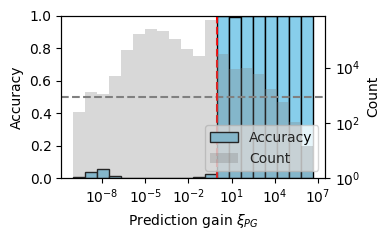

,bin,mean_pred,acc,count
0,"(-0.0009999999, 6.82e-10]",4.639395e-10,0.008000,250.0
1,"(6.82e-10, 4.65e-09]",2.562465e-09,0.040476,1260.0
2,"(4.65e-09, 3.17e-08]",1.457202e-08,0.053571,1120.0
3,"(3.17e-08, 2.16e-07]",1.405656e-07,0.015504,5160.0
4,"(2.16e-07, 1.48e-06]",8.264020e-07,0.001082,42530.0
5,"(1.48e-06, 1.01e-05]",5.009384e-06,0.000599,168555.0
6,"(1.01e-05, 6.86e-05]",3.051904e-05,0.001992,257565.0
7,"(6.86e-05, 0.000468]",1.939497e-04,0.002314,206970.0
8,"(0.000468, 0.00319]",1.242600e-03,0.001846,111080.0
9,"(0.00319, 0.0218]",8.719478e-03,0.003553,48130.0


In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def acc_bins_plot(rr, x_col, subset_filter=None, bins=20,
                  filename="./figures/acc_bins_plot.pdf",
                  caption="Acc Bin Diagram"):
    rr_subset = rr.copy()
    if subset_filter:
        rr_subset = subset_filter(rr_subset)

    rr_subset = rr_subset.dropna(subset=["pred_gain", x_col])

    y_score = rr_subset["pred_gain"]

    # Log-spaced bins
    bin_edges = np.logspace(
        np.log10(max(y_score.min(), 1e-10)),
        np.log10(y_score.max()),
        bins + 1
    )
    rr_subset["bin"] = pd.cut(y_score, bins=bin_edges, include_lowest=True)

    def stat(df):
        y_true = (df[x_col] > 0)
        y_pred = (df["pred_gain"] > 1)
        return pd.Series({
            "mean_pred": df["pred_gain"].mean(),
            "acc": accuracy_score(y_pred, y_true),
            "count": len(df)
        })

    # Aggregate per bin
    binned = rr_subset.groupby("bin").apply(stat).reset_index()

    bin_left = bin_edges[:-1]
    bin_right = bin_edges[1:]
    bin_widths = bin_right - bin_left

    # ---- Plot ----
    fig, ax1 = plt.subplots(figsize=(4, 2.5))

    # Accuracy bars
    ax1.bar(
        bin_left,
        binned["acc"],
        width=bin_widths,
        align="edge",
        edgecolor="black",
        color="skyblue",
        label="Accuracy"
    )
    ax1.set_xscale("log")
    ax1.set_xlabel(r"Prediction gain $\xi_{PG}$")
    ax1.set_ylabel("Accuracy")
    ax1.set_ylim(0, 1)

    ax1.axhline(0.5, color="gray", ls="--")
    ax1.axvline(1, color="r", ls="--")

    # Marginal count histogram (same bins)
    ax2 = ax1.twinx()
    ax2.bar(
        bin_left,
        binned["count"],
        width=bin_widths,
        align="edge",
        color="gray",
        alpha=0.3,
        label="Count"
    )
    ax2.set_ylabel("Count")
    ax2.set_yscale("log")
    ax2.set_ylim(1, max(binned["count"].max(), 1) * 1.5)

    # Legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="lower right")

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

    return binned


acc_bins_plot(
    rr,
    x_col = "validation_score_jsd",
    subset_filter=lambda df: df[df["linear_coder"]==linear_coder],
    bins=20,
    filename=f"./figures/reliability_{linear_coder}_jsd.pdf",
    caption=f"Reliability Diagram {linear_coder}_jsd"
)


/tmp/ipykernel_3334306/2909678911.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()
/tmp/ipykernel_3334306/2909678911.py:35: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()


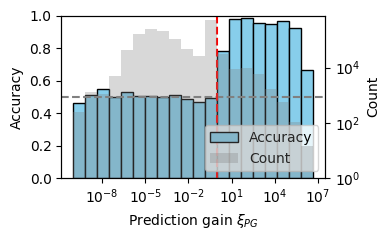

,bin,mean_pred,acc,count
0,"(-0.0009999999, 6.82e-10]",4.639395e-10,0.464000,250.0
1,"(6.82e-10, 4.65e-09]",2.562465e-09,0.510317,1260.0
2,"(4.65e-09, 3.17e-08]",1.457202e-08,0.550893,1120.0
3,"(3.17e-08, 2.16e-07]",1.405656e-07,0.499806,5160.0
4,"(2.16e-07, 1.48e-06]",8.264020e-07,0.528051,42530.0
5,"(1.48e-06, 1.01e-05]",5.009384e-06,0.507413,168555.0
6,"(1.01e-05, 6.86e-05]",3.051904e-05,0.504937,257565.0
7,"(6.86e-05, 0.000468]",1.939497e-04,0.501237,206970.0
8,"(0.000468, 0.00319]",1.242600e-03,0.510092,111080.0
9,"(0.00319, 0.0218]",8.719478e-03,0.484874,48130.0


In [55]:
acc_bins_plot(
    rr,
    x_col = "validation_score_log_p",
    subset_filter=lambda df: df[df["linear_coder"]==linear_coder],
    bins=20,
    filename=f"./figures/reliability_{linear_coder}_log_p.pdf",
    caption=f"Reliability Diagram {linear_coder}_log_p"
)


/tmp/ipykernel_3334306/484891221.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()
/root/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/root/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/root/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/root/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/root/.local/lib/python3.10/site-pac

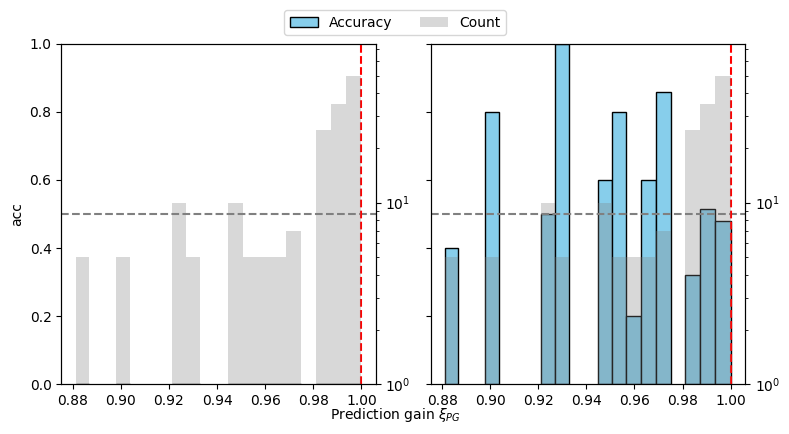

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

def acc_bins_plot_dual(rr, x_cols, subset_filter=None, bins=20,
                       filename="./figures/acc_bins_plot_dual_sideby.pdf",
                       caption="Acc Bin Diagram Dual Side-by-Side"):
    if len(x_cols) != 2:
        raise ValueError("x_cols must be a list of exactly 2 column names")

    # 1 row, 2 columns, wider figure
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), sharey=True)
    fig.subplots_adjust(wspace=0.3, top=0.85)  # leave space for legend

    all_handles, all_labels = [], []

    for i, (ax, x_col) in enumerate(zip(axes, x_cols)):
        rr_subset = rr.copy()
        if subset_filter:
            rr_subset = subset_filter(rr_subset)

        rr_subset = rr_subset.dropna(subset=["pred_gain", x_col])
        y_score = rr_subset["pred_gain"]

        # Log-spaced bins
        bin_edges = np.logspace(
            np.log10(max(y_score.min(), 1e-10)),
            np.log10(y_score.max()),
            bins + 1
        )
        rr_subset["bin"] = pd.cut(y_score, bins=bin_edges, include_lowest=True)

        def stat(df):
            y_true = (df[x_col] > 0)
            y_pred = (df["pred_gain"] > 1)
            return pd.Series({
                "mean_pred": df["pred_gain"].mean(),
                "acc": accuracy_score(y_pred, y_true),
                "count": len(df)
            })

        binned = rr_subset.groupby("bin").apply(stat).reset_index()

        bin_left = bin_edges[:-1]
        bin_right = bin_edges[1:]
        bin_widths = bin_right - bin_left

        # Primary axis: accuracy
        h_acc = ax.bar(
            bin_left,
            binned["acc"],
            width=bin_widths,
            align="edge",
            edgecolor="black",
            color="skyblue",
            label="acc"
        )
        if i == 0:
            ax.set_ylabel("acc")
        ax.set_ylim(0, 1)
        ax.axhline(0.5, color="gray", ls="--")
        ax.axvline(1, color="r", ls="--")
        ax.set_xscale("log")
        # ax.set_xlabel(r"Prediction gain $\xi_{PG}$")
     #   ax.set_title(x_col)
        # Secondary axis: count
        ax2 = ax.twinx()
        h_count = ax2.bar(
            bin_left,
            binned["count"],
            width=bin_widths,
            align="edge",
            color="gray",
            alpha=0.3,
            label="Count"
        )
        # ax2.set_ylabel("Count")
        ax2.set_yscale("log")
        ax2.set_ylim(1, max(binned["count"].max(), 1) * 1.5)

        # Collect handles/labels for combined legend
        all_handles += [h_acc, h_count]
        all_handles = all_handles[0:1] + all_handles[2:3]
        all_labels += ["Accuracy", "Count"]

    # Combined legend at top center
    fig.legend(all_handles, all_labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 1.05))
    fig.text(0.5, 0.02, r"Prediction gain $\xi_{PG}$", ha='center', va='center')

    plt.tight_layout()
    plt.savefig(filename, bbox_inches="tight")
    plt.show()

acc_bins_plot_dual(
rr.head(1000),
x_cols=["validation_score_jsd", "validation_score_log_p"],
subset_filter=lambda df: df[df["linear_coder"]==linear_coder],
bins=20,
filename=f"./figures/reliability_{linear_coder}_dual.pdf",
caption=f"Reliability Diagram {linear_coder} (dual)"
)


/tmp/ipykernel_3334306/2511591213.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binned = rr_subset.groupby("bin").apply(stat).reset_index()
/root/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/root/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/root/.local/lib/python3.10/site-packages/numpy/lib/function_base.py:520: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/root/.local/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/root/.local/lib/python3.10/site-pa

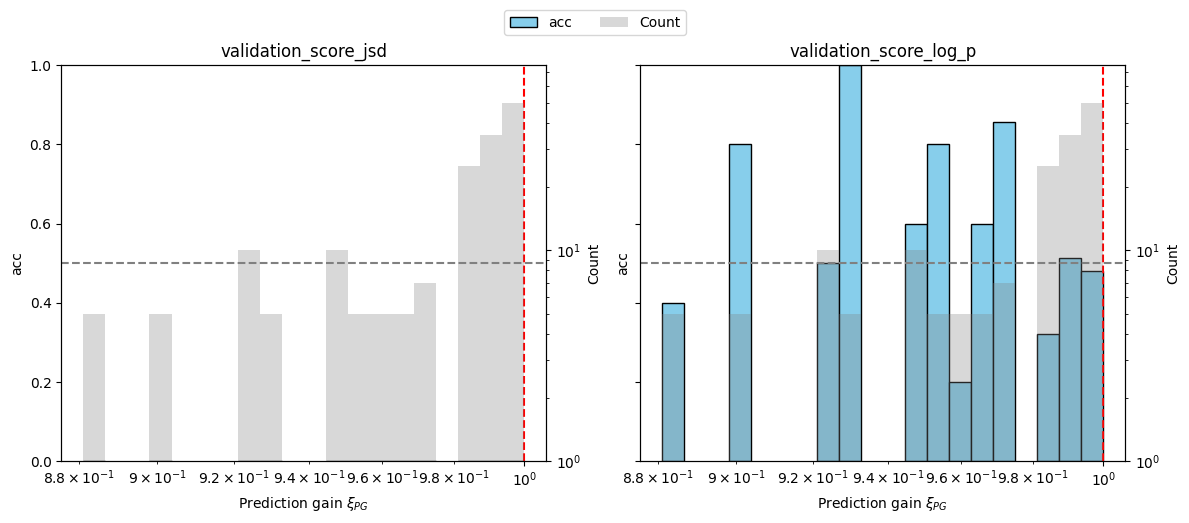

In [15]:
# store_to_tex("accAtThresholdEqualsOne", f"{result_df[result_df["threshold"] == 1].iloc[0]["accuracy"]:.2f}")

In [16]:
# for linear_coder in df_scoring["linear_coder"].unique():
#     print("linear_coder",linear_coder)
#     compute_and_export_correlations(
#         rr, rr_summary,
#         group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","explanation_type","lambda","k"],
#         subset_filter=lambda df: df[(df["lambda"]=="-")& (df["linear_coder"]==linear_coder)],
#         row_label_cols=[ "k","estimator","explanation_type"],
#         sort_cols=["k", "estimator","explanation_type"],
#         filename=f"./tables/validation/per_linear_coder/{linear_coder}.tex",
#         caption=f"Correlation of our score with validation scores for {linear_coder}"
#     )

In [17]:

def categorize(expl_type):
    if "facility" in expl_type:


        regex = r"lambda=(.*)"

        matches = re.finditer(regex, expl_type, re.MULTILINE)
       
        return next(matches).groups()[0]
    elif any(x in expl_type for x in ["DIVINE", "AIDE", "Self"]):
        return "Other"
    else:
        return "Naive"
categorize("10 by facility location from Top-100 least influential (scores closest to zero). lambda=1.0")

'1.0'

## MSECoderProjUSimp

In [18]:

d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)],
    group_cols=["model","train_dataset","train_split","test_dataset","test_split",],
    sort_cols=[],
    row_label_cols=[],
    filename=f"./tables/validation/full/{linear_coder}.tex",
    caption=f"Correlation of our score with validation scores for {linear_coder}"
)
store_to_tex("spearmanPredGainLogPAll", f"{d.data['spearman_pred_gain_log_p'].values[0]:.2f}")
store_to_tex("spearmanPredGainJSDAll", f"{d.data['spearman_pred_gain_jsd'].values[0]:.2f}")

,,,,,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
model,train_dataset,train_split,test_dataset,test_split,,
Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,0.090273,0.060348


In [19]:
d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder) & (df["pred_gain"] > 1)],
    group_cols=["model","train_dataset","train_split","test_dataset","test_split",],
    sort_cols=[],
    row_label_cols=[],
    filename=f"./tables/validation/full/pred_gain_filt{linear_coder}.tex",
    caption=f"Correlation of our score with validation scores for {linear_coder}"
)
store_to_tex("spearmanPredGainLogPAllAboveOne", f"{d.data['spearman_pred_gain_log_p'].values[0]:.2f}")
store_to_tex("spearmanPredGainJSDAllAboveOne", f"{d.data['spearman_pred_gain_jsd'].values[0]:.2f}")

,,,,,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
model,train_dataset,train_split,test_dataset,test_split,,
Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,0.591719,0.382463


In [20]:
compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder) & (df["pred_gain"] > 1)],
    group_cols=["model","train_dataset","train_split","test_dataset","test_split",],
    sort_cols=[],
    row_label_cols=[],
    filename=f"./tables/validation/full/pred_gain_filt{linear_coder}.tex",
    caption=f"Correlation of our score with validation scores for {linear_coder}"
)

,,,,,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
model,train_dataset,train_split,test_dataset,test_split,,
Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,0.591719,0.382463


,,,,,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
model,train_dataset,train_split,test_dataset,test_split,,
Olmo2-1B,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,train,loris3/tulu-3-sft-olmo-2-mixture-0225-sample,test,0.591719,0.382463


### effect of re-ranking

In [21]:

rr_cat = rr.copy()

rr_cat["cat"] = rr_cat["explanation_type_selection"].apply(categorize)
rr_cat = rr_cat[(rr_cat["cat"] != "Other") & (rr_cat["cat"] != "Naive")]
rr_cat = rr_cat[rr_cat["linear_coder"]==linear_coder]

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

def plot_pred_gain_vs_validation(rr_cat, x_col, output_file=None, bins=200, cmap="viridis",
                            single_facet=False, percentile_range=None, df_filter=lambda df: df):
    """
    Create a JointGrid-like 2D histogram of pred_gain vs a validation score with marginal histograms.

    Parameters:
        rr_cat (pd.DataFrame): DataFrame containing 'pred_gain', 'estimator', and x_col
        x_col (str): Column name for x-axis ('validation_score_log_p' or 'validation_score_JSD')
        output_file (str, optional): Path to save PDF. If None, figure is not saved.
        bins (int): Number of bins for 2D histogram
        cmap (str): Colormap to use
        single_facet (bool): If True, plot all data in a single JointGrid
        percentile_range (list or tuple, optional): [lower, upper] percentiles (0–1) to filter pred_gain
    """
    rr_clean = rr_cat.dropna(subset=[x_col, "pred_gain"]).copy()#.sample(frac=0.01)
    
    rr_clean["pred_gain"] = 10* np.log10(rr_clean["pred_gain"])
    display( rr_clean["validation_score_jsd"].describe())
    
    rr_clean = df_filter(rr_clean)
    if percentile_range is not None:
        lower, upper = percentile_range
        lower_thresh = np.percentile(rr_clean["pred_gain"], lower*100)
        upper_thresh = np.percentile(rr_clean["pred_gain"], upper*100)
        rr_clean = rr_clean[(rr_clean["pred_gain"] >= lower_thresh) & (rr_clean["pred_gain"] <= upper_thresh)]

    if single_facet:
        # Single JointGrid
        g = sns.JointGrid(data=rr_clean, x=x_col, y="pred_gain", marginal_ticks=True, height=6)
     #   g.ax_joint.set_yscale("log")
        
        # Create color normalization
        all_counts = np.histogram2d(rr_clean[x_col], rr_clean["pred_gain"], bins=bins)[0]
        norm = mpl.colors.LogNorm(vmin=1, vmax=all_counts.max())
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # Add inset colorbar
        cax = g.fig.add_axes([0.9, 0.25, 0.02, 0.5])
        cax.set_ylabel("count (log)")
        # Plot 2D histogram
        g.plot_joint(
            sns.histplot,
            bins=bins,
            pmax=1,
            cbar=True,
            cbar_ax=cax,
            cmap=cmap,
            discrete=(False, False),
            log_scale=(False, False)
        )
        cax.set_ylabel("count (log)")
        # Plot marginal histograms
        g.plot_marginals(sns.histplot, element="step", color="black")

        # Reference line at x=0
        g.ax_joint.axvline(x=0, color='red', linestyle=':', linewidth=1)
        g.ax_joint.axhline(y=1, color='red', linestyle=':', linewidth=1)
        if "jsd" in x_col:
            xmin, xmax = 0, 3

            # joint
            g.ax_joint.set_xlim(xmin, xmax)

            # x marginal
            g.ax_marg_x.set_xlim(xmin, xmax)


        g.set_axis_labels("Fine-tuning Validation Score", "Selection Quality Score (Prediction Gain)[dB]")
        g.fig.subplots_adjust(top=0.9, right=0.88)

        if output_file:
            g.fig.savefig(output_file, format="pdf", bbox_inches="tight")
        plt.show()
    else:
        # Original FacetGrid by estimator
        g = sns.FacetGrid(rr_clean, col="estimator", col_wrap=4, height=3, sharex=True, sharey=True)
        g.map_dataframe(
            sns.histplot,
            x=x_col,
            y="pred_gain",
            bins=bins,
            pmax=1,
            cbar=False,
            log_scale=(False, False),
            cmap=cmap,
        )
        for ax in g.axes.flatten():
            ax.axvline(x=0, color='red', linestyle=':', linewidth=1)
        all_counts = np.histogram2d(rr_clean[x_col], rr_clean["pred_gain"], bins=bins)[0]
        norm = mpl.colors.LogNorm(vmin=1, vmax=all_counts.max())
        sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array([])

        # Add colorbar to the figure
        cbar_ax = g.fig.add_axes([0.7, 0.15, 0.01, 0.7])  # adjust position as needed
        cbar = g.fig.colorbar(sm, cax=cbar_ax)
        cbar.set_label("count (log)")
        fig = g.fig
        fig.subplots_adjust(right=0.9, top=0.9, bottom=0.1, hspace=0.1, wspace=0.1)
        if output_file:
            fig.savefig(output_file, format="pdf", bbox_inches="tight")
        plt.show()



In [48]:
# plot_pred_gain_vs_validation(rr_cat, "validation_score_jsd", single_facet=True, output_file="figures/pred_gain_validation_jsd_single.pdf", percentile_range=[0.0, 1])

In [ ]:
plot_pred_gain_vs_validation(rr_cat, "validation_score_log_p", single_facet=True, output_file="figures/pred_gain_validation_logp_single.pdf", percentile_range=[0.0, 1])

count    980975.000000
mean        -25.600768
std          22.745089
min        -145.064078
25%         -45.582688
50%         -31.671034
75%          -0.184692
max          46.006871
Name: pred_gain, dtype: float64

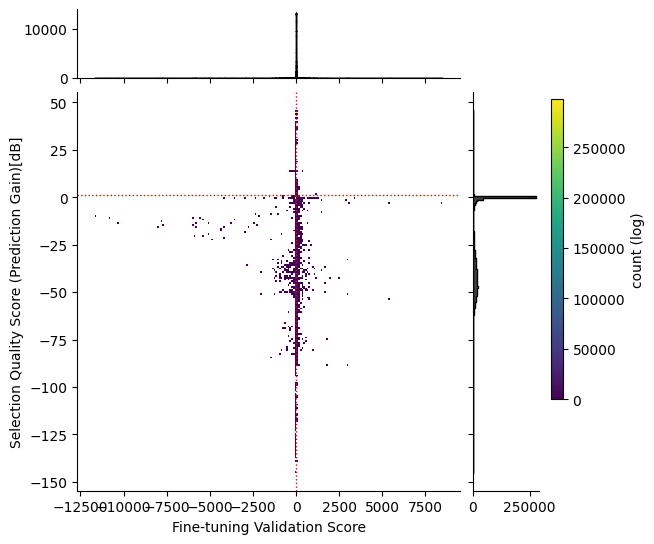

In [23]:
# plot_pred_gain_vs_validation(rr_cat, "validation_score_jsd", single_facet=True, output_file="figures/pred_gain_validation_JSD_single.pdf")

count    980975.000000
mean        -25.600768
std          22.745089
min        -145.064078
25%         -45.582688
50%         -31.671034
75%          -0.184692
max          46.006871
Name: pred_gain, dtype: float64

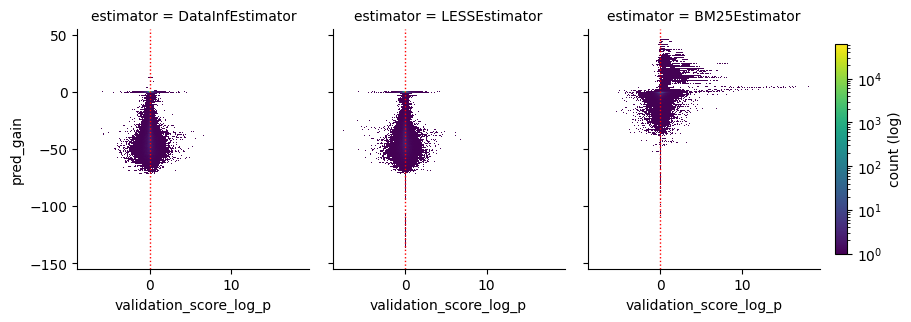

In [24]:
plot_pred_gain_vs_validation(rr_cat, "validation_score_log_p", output_file="figures/pred_gain_validation_logp.pdf")

count    980975.000000
mean        -25.600768
std          22.745089
min        -145.064078
25%         -45.582688
50%         -31.671034
75%          -0.184692
max          46.006871
Name: pred_gain, dtype: float64

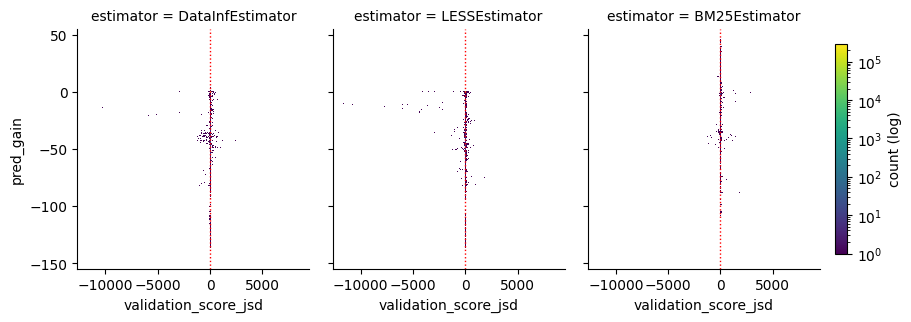

In [25]:
plot_pred_gain_vs_validation(rr_cat, "validation_score_jsd", output_file="figures/pred_gain_validation_JSD.pdf")


In [26]:

d = compute_and_export_correlations(
    rr_cat,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split", "cat"],
    sort_cols=["estimator","cat"],
    row_label_cols=["estimator", "cat",],
    filename=f"./tables/validation/per_strategy/{linear_coder}.tex",
    caption=f"Per selection-type strategy of our score with validation scores for {linear_coder}"
)



In [27]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# sample sizes (replace with your actual values)


result = []
df_naive = d.data.xs("0.0", level="cat")

for cat in set(d.data.index.get_level_values("cat")):
    df_fl = d.data.xs(cat, level="cat")

    # Fisher z-transform
    z_naive = np.arctanh(df_naive[["spearman_pred_gain_log_p"]])
    z_fl = np.arctanh(df_fl[["spearman_pred_gain_log_p"]])

    # raw difference
    diff = z_naive - z_fl

    # standard error
    se = np.sqrt(1/(df_naive["n"] - 3) + 1/(df_fl["n"] - 3))

    # z statistic as pandas Series
    z_stat = pd.Series(
        (diff["spearman_pred_gain_log_p"] / se).values,
        index=diff.index,
        name="z_stat"
    )

    # p-values as pandas Series
    pvals_more_negative = pd.Series(
        1 - norm.cdf(z_stat.values),
        index=z_stat.index,
        name="pvalue_more_negative"
    )

    df_out = diff.assign(
        cat=cat,
        z_stat=z_stat,
        pvalue_more_negative=pvals_more_negative
    )

    result.append(df_out)

final_df = pd.concat(result).set_index("cat", append=True)
final_df["correlation_more_negative"] = final_df["pvalue_more_negative"] < 0.05

df = final_df[final_df["correlation_more_negative"]].index.to_frame(index=False)

grouped = df.groupby('estimator')['cat'].apply(lambda x: ','.join(sorted(x, key=float)))

formatted = ', '.join([f"{est.split('Estimator')[0]} $\\lambda=\\{{ {vals} \\}}$" 
                       for est, vals in grouped.items()])

store_to_tex("settingsWhereFLDecreasesRho", formatted)

In [28]:
import pandas as pd
import numpy as np
from scipy.stats import norm

# sample sizes (replace with your actual values)


result = []
df_naive = d.data.xs("0.0", level="cat")

for cat in set(d.data.index.get_level_values("cat")):
    df_fl = d.data.xs(cat, level="cat")

    # Fisher z-transform
    z_naive = np.arctanh(df_naive[["spearman_pred_gain_log_p"]])
    z_fl = np.arctanh(df_fl[["spearman_pred_gain_log_p"]])

    # raw difference
    diff = z_naive - z_fl

    # standard error
    se = np.sqrt(1/(df_naive["n"] - 3) + 1/(df_fl["n"] - 3))

    # z statistic as pandas Series
    z_stat = pd.Series(
        (diff["spearman_pred_gain_log_p"] / se).values,
        index=diff.index,
        name="z_stat"
    )

    # p-values as pandas Series
    pvals = pd.Series(norm.cdf(z_stat.values),
                    index=z_stat.index,
                    name="pvalue")

    df_out = diff.assign(
        cat=cat,
        z_stat=z_stat,
        pvalue=pvals
    )

    result.append(df_out)

final_df = pd.concat(result).set_index("cat", append=True)
final_df["correlation_less_negative"] = final_df["pvalue"] < 0.05

df = final_df[final_df["correlation_less_negative"]].index.to_frame(index=False)

grouped = df.groupby('estimator')['cat'].apply(lambda x: ','.join(sorted(x, key=float)))

formatted = ', '.join([f"{est.split('Estimator')[0]} $\\lambda=\\{{ {vals} \\}}$" 
                       for est, vals in grouped.items()])

store_to_tex("settingsWhereFLIncreasesRho", formatted)

In [29]:
import pandas as pd
import numpy as np

result = []
df_naive = d.data.xs("0.0", level="cat")

for cat in set(d.data.index.get_level_values("cat")):
    df_FL = d.data.xs(cat, level="cat")

    z_naive = np.arctanh(df_naive[["spearman_pred_gain_log_p"]])
    z_FL = np.arctanh(df_FL[["spearman_pred_gain_log_p"]])

    abs_diff_log_p = z_naive - z_FL
    abs_diff_log_p["cat"] = cat  # add as a column
    
    
    result.append(abs_diff_log_p)

final_df = pd.concat(result).set_index("cat", append=True)
final_df


,,spearman_pred_gain_log_p
estimator,cat,
BM25Estimator,1.0,0.065989
DataInfEstimator,1.0,-0.000405
LESSEstimator,1.0,-0.000858
BM25Estimator,0.25,-0.000698
DataInfEstimator,0.25,-0.005832
LESSEstimator,0.25,0.013124
BM25Estimator,0.0,0.000000
DataInfEstimator,0.0,0.000000
LESSEstimator,0.0,0.000000


### mean per type

In [30]:


compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split", "explanation_type_no_k"],
    sort_cols=["estimator", "explanation_type_no_k"],
    row_label_cols=[ "explanation_type_no_k","estimator"],
    filename=f"./tables/validation/per_selection_type/{linear_coder}.tex",
    caption=f"Per selection-type correlation of our score with validation scores for {linear_coder}"
)



,,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
explanation_type_no_k,estimator,,
The test instance (as a sanity check),BM25Estimator,-0.447092,0.655923
Top-X least influential (scores closest to zero),BM25Estimator,-0.005707,-0.082024
Top-X most influential (scores with largest absolute value),BM25Estimator,0.318511,0.259171
X by AIDE from Top-100.,BM25Estimator,0.269652,0.307352
X by AIDE from Top-X0.,BM25Estimator,0.351548,0.281984
X by AIDE from Top-X00.,BM25Estimator,0.269131,0.233610
X by DIVINE from Top-100 least influential (scores closest to zero).,BM25Estimator,-0.010436,-0.091473
X by DIVINE from Top-100 most influential (scores with largest absolute value).,BM25Estimator,0.166979,0.145669
X by DIVINE from Top-X0 least influential (scores closest to zero).,BM25Estimator,0.001653,-0.165567


,,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
explanation_type_no_k,estimator,,
The test instance (as a sanity check),BM25Estimator,-0.447092,0.655923
Top-X least influential (scores closest to zero),BM25Estimator,-0.005707,-0.082024
Top-X most influential (scores with largest absolute value),BM25Estimator,0.318511,0.259171
X by AIDE from Top-100.,BM25Estimator,0.269652,0.307352
X by AIDE from Top-X0.,BM25Estimator,0.351548,0.281984
X by AIDE from Top-X00.,BM25Estimator,0.269131,0.233610
X by DIVINE from Top-100 least influential (scores closest to zero).,BM25Estimator,-0.010436,-0.091473
X by DIVINE from Top-100 most influential (scores with largest absolute value).,BM25Estimator,0.166979,0.145669
X by DIVINE from Top-X0 least influential (scores closest to zero).,BM25Estimator,0.001653,-0.165567


### mean per k

In [31]:


compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[ (df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","k"],
    sort_cols=[ "k","estimator",],
    row_label_cols=[ "k","estimator"],
    filename=f"./tables/validation/per_k/{linear_coder}.tex",
    caption=f"Per k correlation of our score with validation scores for {linear_coder}"
)



### mean per estimator

In [32]:


d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split",],
    sort_cols=[ "estimator",],
    row_label_cols=[ "estimator"],
    filename=f"./tables/validation/per_estimator/{linear_coder}.tex",
    caption=f"Per estimatior correlation of our score with validation scores for {linear_coder}"
)
for estimator_name, value in d.data['spearman_pred_gain_log_p'].items():
    store_to_tex(f"spearmanPredGainLogP{estimator_name}", f"{value:.2f}")
for estimator_name, value in d.data['spearman_pred_gain_jsd'].items():
    store_to_tex(f"spearmanPredGainJSD{estimator_name}", f"{value:.2f}")

,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
estimator,,
BM25Estimator,0.223922,0.218720
DataInfEstimator,0.026385,0.011682
LESSEstimator,0.026814,0.021225


### mean per estimator if pred_gain > 1

In [33]:


df = rr[(rr["linear_coder"]==linear_coder)]
for estimator, value in (df["pred_gain"].groupby(df["estimator"]).apply(lambda x: (x > 1).mean())).items():
    print(estimator,value)
    store_to_tex(f"fractionPredGainAboveOne{estimator.replace('Estimator', '')}", f"{value*100:.2f}\%")


BM25Estimator 0.20005
DataInfEstimator 0.008533926204626107
LESSEstimator 0.008808176514453656


In [34]:
d = compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["linear_coder"]==linear_coder) & (df["pred_gain"] > 1)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split",],
    sort_cols=[ "estimator",],
    row_label_cols=[ "estimator"],
    filename=f"./tables/validation/per_estimator/{linear_coder}.tex",
    caption=f"Per estimatior correlation of our score with validation scores for {linear_coder}"
)
for estimator_name, value in d.data['spearman_pred_gain_log_p'].items():
    store_to_tex(f"spearmanPredGainLogPAboveOne{estimator_name}", f"{value:.2f}")
for estimator_name, value in d.data['spearman_pred_gain_jsd'].items():
    store_to_tex(f"spearmanPredGainJSDAboveOne{estimator_name}", f"{value:.2f}")

,"$\rho (pred_gain, \log_p)$","$\rho (pred_gain, JSD)$"
estimator,,
BM25Estimator,0.529243,0.314269
DataInfEstimator,-0.424335,0.656108
LESSEstimator,-0.391046,0.683053


## per lambda

In [35]:

compute_and_export_correlations(
    rr,
    subset_filter=lambda df: df[(df["lambda"]!="-")& (df["linear_coder"]==linear_coder)],
    group_cols=["estimator","model","train_dataset","train_split","test_dataset","test_split","lambda"],
    sort_cols=[ "estimator","lambda"],
    row_label_cols=[ "estimator","lambda"],
    filename=f"./tables/validation/per_lambda/{linear_coder}.tex",
    caption=f"Per lambda correlation of our score with validation scores for {linear_coder}"
)

